# 📘 Módulo 2 — Introduction & Description Satistics
## Livro Didático Aplicado (Híbrido)

- 🔵 **Conteúdo oficial do módulo 2 (IBM)**
- 🟣 **Conteúdo expandido (Livro Didático)**
- 🟠 **Conteúdo avançado (Opcional, matemático)**

Este notebook foi pensado como:
- material de estudo profundo,
- alinhado ao curso IBM,
- mas com muito mais teoria, exemplos, simulações e demonstrações.

Você pode:
- seguir só o que é 🔵 (curso),
- ou mergulhar no 🟣 (livro didático),
- e abrir o 🟠 (avançado) quando quiser ir mais fundo.

# 📚 Índice

1. [Introdução à estatística](#1-introdução-à-estatística)  
2. [Tipos de dados](#2-tipos-de-dados)  
3. [População, amostra e parâmetros](#3-população-amostra-e-parâmetros)  
4. [Medidas de tendência central](#4-medidas-de-tendência-central)  
5. [Medidas de dispersão](#5-medidas-de-dispersão)  
6. [Visualização de dados](#6-visualização-de-dados)  
7. [Aplicações com teaching ratings](#7-aplicações-com-teaching-ratings)  
8. [Exercícios guiados](#8-exercícios-guiados)  
9. [Diagramas conceituais](#9-diagramas-conceituais)  
10. [Apêndice matemático avançado](#10-apêndice-matemático-avançado)  

---
# 0. Setup — bibliotecas e dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

🔵 **Conteúdo oficial do módulo 2 (IBM)**  
Usaremos o mesmo dataset do curso: *teaching ratings*.

In [ ]:
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv"
ratings_df = pd.read_csv(ratings_url)
ratings_df.to_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv", index=False)
ratings_df.head()

In [3]:
# base de dados local
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")


**Data Description**
| Variable | Description | obs. |
|---------|-------------| --- |
| minority | O instrutor pertence a um grupo minoritário (non-Caucasian)? |
| age | Idade do professor |
| gender | Indica se o instrutor é male ou female |
| credits | O curso é um single-credit elective? | O curso é uma disciplina eletiva de um crédito.
| beauty | Rating da aparência física do instrutor, avaliada por seis estudantes e padronizada com média zero |
| eval | Teaching evaluation score (1 = very unsatisfactory, 5 = excellent) | Nota de avaliação do ensino
| division | O curso é upper ou lower division? | O curso é divisão superior ou inferior?
| native | O instrutor é native English speaker? | O instrutor é falante nativo de inglês?
| tenure | O instrutor está em tenure track? | O instrutor está em regime de estabilidade?
| students | Número de estudantes que participaram da avaliação |
| allstudents | Número total de estudantes matriculados |
| prof | Identificador do instrutor |

---
# 1. Introdução à estatística
<a id="1-introdução-à-estatística"></a>

🟣 **Conteúdo expandido (Livro Didático)**

Estatística é a ciência que:
- coleta dados,
- organiza e resume,
- analisa,
- interpreta,
- e comunica resultados.

Ela aparece em:
- previsões de clima,
- taxas de desemprego,
- preços de moradia,
- desempenho de atletas,
- salários médios,
- pesquisas eleitorais,
- estudos de saúde, educação, economia.

🔵 **Conexão com o curso**

O módulo 2 introduz:
- tipos de dados,
- medidas de tendência central (média, mediana, moda),
- medidas de dispersão (variância, desvio padrão),
- estatísticas descritivas com Python,
- uso do dataset *teaching ratings*.

🟣 **Estatística descritiva vs inferencial**

- **Estatística descritiva**: descreve o que os dados mostram.
  - Ex.: média de idade, desvio padrão de salários, histograma de notas.
- **Estatística inferencial**: tira conclusões sobre uma população a partir de uma amostra.
  - Ex.: estimar média populacional, testar hipóteses, construir intervalos de confiança.

---
# 2. Tipos de dados
<a id="2-tipos-de-dados"></a>

🔵 **Conteúdo oficial do módulo 2 (IBM)**  
O curso apresenta:
- dados transversais (cross-sectional),
- séries temporais (time series),
- dados de painel,
- variáveis categóricas, ordinais, contínuas, de intervalo, de razão.

## 2.1 Estrutura dos dados

🟣 **Tipos de estrutura de dados**

- **Cross-sectional (transversal)**: 
  - várias unidades observadas em um único ponto no tempo.
    - Ex.: avaliação de vários cursos em um semestre.
- **Time series (série temporal)**: 
  - uma variável observada ao longo do tempo.
    - Ex.: taxa de desemprego mensal.
- **Panel data (dados em painel)**: 
  -combinação de cross-section e time series.
    - Ex.: acompanhar os mesmos indivíduos ao longo de vários anos.

🔵 **Exemplo com o dataset teaching ratings**

Pergunta: os dados são **cross-sectional** ou **time series**?

In [ ]:
ratings_df.head(20)

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


🟣 **Interpretação**

- Não há variável de tempo (data, ano, semestre).
- Cada linha é um curso/instrutor em um momento específico.

👉 Conclusão: o dataset é **cross-sectional**.

## 2.2 Tipos de variáveis

🟣 **Classificação das variáveis**

- **Categóricas**:
  - *Nominais*
    - Ex.: `gender` (male, female), `minority` (yes, no), `native`.
  - *Ordinais*:
    - Ex.: níveis de satisfação (ruim, regular, bom, ótimo).

- **Numéricas (quantitativas)**:
  - **Discretas**: contagens (número de alunos).
  - **Contínuas**: medidas (altura, peso, tempo).

  - **Intervalo**:
    - Ex.: temperatura em °C (zero não é ausência de temperatura).

  - **Razão (proporção)**:
    - Ex.: renda, distância, peso (zero significa ausência da quantidade).

🔵 **Exemplo com teaching ratings**

In [ ]:
ratings_df.dtypes

minority               str
age                  int64
gender                 str
credits                str
beauty             float64
eval               float64
division               str
native                 str
tenure                 str
students             int64
allstudents          int64
prof                 int64
PrimaryLast          int64
vismin               int64
female               int64
single_credit        int64
upper_division       int64
English_speaker      int64
tenured_prof         int64
dtype: object

🟣 **Mapeando tipos**

- `minority`, `gender`, `division`, `native`, `tenure` → categórica nominal.
- `age`, `beauty`, `eval`, `students`, `allstudents` → numéricas.
- `prof` → identificador (categórica ordinais).

<details>
<summary>🟠 Conteúdo avançado (opcional) — visão formal de tipos de dados</summary>

Em termos mais formais:

- Variáveis categóricas podem ser vistas como funções:

$$
X: \Omega \to \{c_1, c_2, \dots, c_k\}
$$

- Variáveis numéricas:

$$
X: \Omega \to \mathbb{R}
$$

A escolha do tipo de variável determina:
- quais operações fazem sentido (média, variância, proporções),
- quais gráficos são apropriados (barras, histogramas, boxplots),
- quais modelos estatísticos podem ser usados.

</details>

---
# 3. População, amostra e parâmetros
<a id="3-população-amostra-e-parâmetros"></a>

🟣 **Conceitos fundamentais**

> - **População**: conjunto de todos os elementos de interesse.  
    > 👉🏼 **Parâmetro**: medida numérica da população (ex.: média populacional).

> - **Amostra**: subconjunto da população.  
    > 👉🏼 **Estatística**: medida numérica calculada a partir da amostra (ex.: média amostral).


🔵 **Conexão com o curso**

O módulo 2 discute:
- por que usamos amostras,
- custo de coletar dados da população inteira,
- símbolos gregos para parâmetros (μ, σ²),
- símbolos latinos para estatísticas (x̄, s²).

## 3.1 População vs amostra

🟣 **Exemplo intuitivo**

- **População**: todos os cursos de uma universidade.
- **Amostra**: 463 cursos do dataset *teaching ratings*.

O que temos no arquivo CSV é uma **amostra** de uma população maior.

In [ ]:
ratings_df.shape
# (linhas, colunas)

(463, 19)

🟣 **Notação**

- **Média populacional**: $ \mu $
- **Variância populacional**: $ \sigma^2 $
- **Média amostral**: $ \bar{X} $
- **Variância amostral**: $ s^2 $

🟠 **Conteúdo avançado — fórmulas de média e variância**

<br>

| Nome | Desvio Absoluto | Média | Variância | Desvio Padrão |
|-|-|-|-|-|
| **Polulação (Population)** <br> finita com $N$ elementos: | $$ \sum_{i=1}^N (x_i - \mu) = 0 $$ | $$ \mu = \frac{1}{N} \sum_{i=1}^N x_i $$ | $$ \sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2 $$ | $$ \sigma = \sqrt{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2} $$ |
| **Amostra (Sample)** <br> de tamanho $n$: | $$ \sum_{i=1}^N (x_i - \bar{X}) = 0 $$ | $$ \bar{X} = \frac{1}{n} \sum_{i=1}^n x_i $$ | $$ s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{X})^2 $$ | $$ \sigma = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{X})^2} $$ |

---
# 4. Medidas de tendência central
<a id="4-medidas-de-tendência-central"></a>

🔵 **Conteúdo oficial do módulo 2 (IBM)**  
O curso apresenta:
- média,
- mediana,
- moda,
- uso de `pandas.describe()` para estatísticas resumidas.

In [37]:
ratings_df.describe()

,age,beauty,eval,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
count,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,48.365011,6.271140e-08,3.998272,36.624190,55.177106,45.434125,0.203024,0.138229,0.421166,0.058315,0.660907,0.939525,0.779698
std,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902,0.402685,0.345513,0.494280,0.234592,0.473913,0.238623,0.414899
min,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4.1 Média

🟣 **Definição**

A **média** é a soma de todas as observações dividida pelo número de observações:

- $ \sum_{i=1}^n x_i = \sum_{} x_i $ 

- $ \bar{X} = \frac{1}{n} \sum_{} x_i = \frac{\sum_{} x_i}{n} $

Ela representa um “centro de gravidade” dos dados.

In [8]:
ratings_df["eval"].mean()

np.float64(3.9982721362721585)

🟣 **Interpretação**

- A média de `eval` indica a avaliação média dos instrutores.
- É sensível a valores extremos **(outliers)**.

## 4.2 Mediana

🟣 **Definição**

A **mediana** é o valor que divide os dados ordenados em duas metades:
- 50% das observações ficam abaixo,
- 50% ficam acima.

Ela é mais robusta a outliers do que a média.

In [9]:
ratings_df["eval"].median()

np.float64(4.0)

## 4.3 Moda

🟣 **Definição**

A **moda** é o valor que ocorre com maior frequência.

Em variáveis categóricas, a moda é especialmente útil.

In [10]:
ratings_df["gender"].mode()

0    male
Name: gender, dtype: str

🟠 **Conteúdo avançado — propriedades da média**

Uma propriedade importante, desvio absoluto:

<br>

| Ou seja | Função |
|-|-|
| A soma dos desvios em relação à média é sempre zero. |  $$  \sum_{i=1}^n (x_i - \bar{X}) = 0  $$ |

<br>

> Isso justifica o uso da média como centro de referência para medir dispersão.


---
# 5. Medidas de dispersão
<a id="5-medidas-de-dispersão"></a>

🔵 **Conteúdo oficial do módulo 2 (IBM)**  
O curso apresenta:
- variância,
- desvio padrão,
- interpretação da “curva em forma de sino”,
- importância de média + desvio padrão juntos.

## 5.1 Amplitude (range)

🟣 **Definição**

A amplitude é a diferença entre o valor máximo e o mínimo:  
> **$ \text{Amplitude} = \max(x_i) - \min(x_i) $**

In [5]:
ratings_df["age"].max() - ratings_df["age"].min()

np.int64(44)

## 5.2 Variância e desvio padrão

🟣 **Definições**

<br>

|| Dispersão | Função Identidade |
|-|-|-|
| **Variância amostral:**  | $$ s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{X})^2 $$ | $$ s^2 = \frac{\sum_{} (x_i - \bar{X})^2}{n-1} $$ |
| **Desvio Padrão** | $$ s = \sqrt{\frac{\sum_{} (x_i - \bar{X})^2}{n-1}} $$ | $$ s = \sqrt{s^2} $$ |


In [6]:
ratings_df["age"].var(), ratings_df["age"].std()

(np.float64(96.09375146092209), np.float64(9.80274203786482))

🟣 **Interpretação**

- A variância mede a dispersão em unidades ao quadrado.
- O desvio padrão traz a dispersão de volta para as mesmas unidades da variável.
- Média e desvio padrão **devem ser interpretados juntos**.

🟠 **Conteúdo avançado — variância como medida de energia**</summary>**

> - A variância pode ser vista como a “energia” dos desvios em relação à média:
>   - Em muitas áreas (processamento de sinais, machine learning), a variância está ligada à noção de energia, ruído, incerteza.


<br>

## 🟣 5.3 Padronização (Z-score)

A padronização transforma uma variável numérica em uma escala comum, onde:

- a **média passa a ser 0**,  
- o **desvio padrão passa a ser 1**,  
- e os valores passam a ser medidos em **unidades de desvio padrão**.

A transformação é dada por:

| $$ z_i = \frac{x_i - \bar{X}}{s} $$ |
|-|

onde:

- $\bar{X}$ é a média da variável,  
- $s$ é o desvio padrão amostral.

<br>

✔ **O que acontece após a padronização?**

A nova variável $Z$ sempre terá:

- **média igual a 0**,  
- **desvio padrão igual a 1**.

Isso significa que cada valor representa **quantos desvios padrão** ele está acima ou abaixo da média.

<br>

✔ **Como interpretar valores padronizados?**

- $z = 0$ → valor exatamente na média  
- $z = 1$ → 1 desvio padrão acima da média  
- $z = -1$ → 1 desvio padrão abaixo da média  
- $|z| > 2$ → valores incomuns (possíveis outliers)

<br>

✔ **Por que padronizar?**

- Padronização é útil quando:
    - queremos comparar variáveis em escalas diferentes,  
    - queremos visualizar dispersão de forma mais clara,  
    - vamos usar modelos estatísticos (como regressão),  
    - queremos evitar que variáveis com valores grandes dominem análises.

<br>

✔ **Exemplo no dataset *teaching ratings***

A variável `beauty` já vem padronizada pelos autores do estudo:

- média = 0  
- desvio padrão = 1  

Isso significa que `beauty` não representa “beleza absoluta”, mas sim **beleza relativa**, medida em desvios padrão.

Essa interpretação será essencial no Módulo 3, quando analisarmos gráficos que mostram:

- média,  
- dispersão,  
- e faixas de $\pm 1$ desvio padrão.

<br>

🟠 **Conteúdo avançado — Geometria da padronização**

A padronização pode ser entendida como uma **transformação linear** aplicada ao eixo dos dados:

| $$ Z = \frac{X - \bar{X}}{s} $$ |
|-|

<br>

**Essa transformação ocorre em duas etapas geométricas:**

1. <u>Deslocamento do ponto central (translação)</u>
- Antes da padronização, o centro dos dados está em $\bar{X}$:

    ```text
    <---------|-------------------->
            μ
    ```

- Ao subtrair a média: 
    |$$ X' = X - \bar{X} $$|
    |-|
    
    <br>
    - todo o eixo é deslocado, e o ponto que antes era $\bar{X}$ passa a ser **0**:

    ```text
    <----------------|------------->
                    0
    ```

    > Ou seja, o **centro geométrico** da distribuição é movido para a origem.

<br>

2. <u>Ajuste da escala (dilatação/contração)</u>
- Dividir pelo desvio padrão redefine a unidade de medida: 

    |$$ Z = \frac{X'}{s} $$|
    |-|

<br>

- Agora, **1 unidade no eixo representa 1 desvio padrão**:

    ```text
    -2    -1     0     +1    +2
    |-----|-----|-----|-----|
    ```

    > O centro permanece em 0, mas a escala é normalizada.

<br>

**Resultado**

- A variável passa a viver em um espaço onde:
    - a média é **0** (centro geométrico),
    - o desvio padrão é **1** (unidade de medida),
    - e os valores representam **distâncias relativas** em unidades naturais de dispersão.

- Essa transformação é fundamental em:
    - regressão,
    - PCA,
    - machine learning,
    - análise multivariada.

<br>

---
# 6. Visualização de dados
<a id="6-visualização-de-dados"></a>

🔵 **dataset teaching ratings**

In [8]:
ratings_df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


🟣 **Ferramentas básicas**

- **Histograma**: distribuição de uma variável numérica.
- **Gráfico de barras**: contagem de categorias.
- **Boxplot**: mediana, quartis, outliers.

## 6.1 Histograma

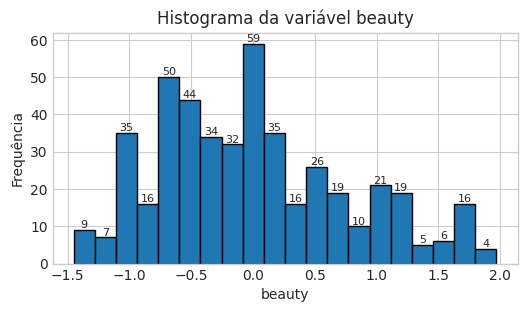

In [34]:
counts, bin_edges = np.histogram(ratings_df["beauty"], bins=20)

plt.figure(figsize=(6, 3))                                                                  # Tamanho da figura
counts, bins, patches = plt.hist(ratings_df["beauty"], bins=20, edgecolor="black")           # plt.hist(ratings_df["beauty"], bins=20, edgecolor="black")
plt.xlabel("beauty"); plt.ylabel("Frequência"); plt.title("Histograma da variável beauty")
# adicionar os números sobre cada barra
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(patch.get_x() + patch.get_width() / 2, count, int(count), ha="center", va="bottom", fontsize=8)
        
plt.show()

🟣 **Comentário**

- A maior parte dos valores de `beauty` está próxima de 0.
- A distribuição é levemente assimétrica.
- Lembrando: `beauty` foi padronizada com média zero.

## 6.2 Gráfico de barras

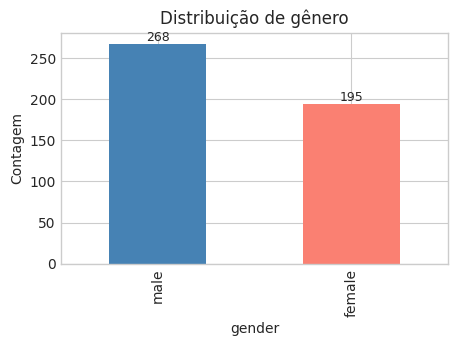

In [ ]:
plt.figure(figsize=(5, 3))
ax = ratings_df["gender"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.xlabel("gender")
plt.ylabel("Contagem")
plt.title("Distribuição de gênero")
# adicionar os valores acima das barras
for p in ax.patches:
    ax.annotate(text=str(int(p.get_height())), xy=(p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)

plt.show()

---
# 7. Aplicações com teaching ratings
<a id="7-aplicações-com-teaching-ratings"></a>

🔵 **Conteúdo oficial do lab de Estatísticas Descritivas**

O lab pede:
- identificar se os dados são cross-sectional ou time series,
- calcular média, mediana, mínimo, máximo de `students`,
- produzir tabela de estatísticas descritivas,
- criar histograma de `beauty`,
- comparar `beauty` por `gender`,
- calcular porcentagem de tenure por gênero,
- responder questões práticas.

## 7.1 Estrutura do dataset

In [38]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minority         463 non-null    str    
 1   age              463 non-null    int64  
 2   gender           463 non-null    str    
 3   credits          463 non-null    str    
 4   beauty           463 non-null    float64
 5   eval             463 non-null    float64
 6   division         463 non-null    str    
 7   native           463 non-null    str    
 8   tenure           463 non-null    str    
 9   students         463 non-null    int64  
 10  allstudents      463 non-null    int64  
 11  prof             463 non-null    int64  
 12  PrimaryLast      463 non-null    int64  
 13  vismin           463 non-null    int64  
 14  female           463 non-null    int64  
 15  single_credit    463 non-null    int64  
 16  upper_division   463 non-null    int64  
 17  English_speaker  463 non-nu

In [39]:
ratings_df.shape

(463, 19)

## 7.2 Estatísticas descritivas gerais

In [40]:
ratings_df.describe()

,age,beauty,eval,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
count,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,48.365011,6.271140e-08,3.998272,36.624190,55.177106,45.434125,0.203024,0.138229,0.421166,0.058315,0.660907,0.939525,0.779698
std,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902,0.402685,0.345513,0.494280,0.234592,0.473913,0.238623,0.414899
min,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 7.3 Medidas para a variável students

In [41]:
students_mean = ratings_df["students"].mean()
students_median = ratings_df["students"].median()
students_min = ratings_df["students"].min()
students_max = ratings_df["students"].max()
students_mean, students_median, students_min, students_max

(np.float64(36.62419006479482), np.float64(23.0), np.int64(5), np.int64(380))

🟣 **Interpretação**

- Média de alunos por curso,
- Mediana (curso “típico”),
- Mínimo e máximo (extremos de tamanho de turma).

<br>

🟠  **Gráfico de interpretação**

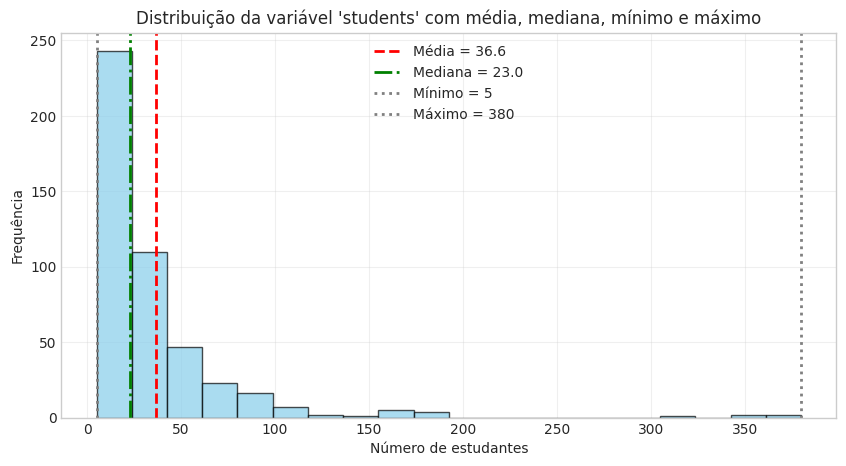

In [71]:
# Estatísticas
students_mean = ratings_df["students"].mean()
students_median = ratings_df["students"].median()
students_min = ratings_df["students"].min()
students_max = ratings_df["students"].max()

plt.figure(figsize=(10, 5))

# Histograma
plt.hist(ratings_df["students"], bins=20, color="skyblue", edgecolor="black", alpha=0.7)

# Linhas verticais
plt.axvline(students_mean, color="red", linestyle="--", linewidth=2, label=f"Média = {students_mean:.1f}")
plt.axvline(students_median, color="green", linestyle="-.", linewidth=2, label=f"Mediana = {students_median:.1f}")
plt.axvline(students_min, color="gray", linestyle=":", linewidth=2, label=f"Mínimo = {students_min}")
plt.axvline(students_max, color="gray", linestyle=":", linewidth=2, label=f"Máximo = {students_max}")

# Títulos e legendas
plt.title("Distribuição da variável 'students' com média, mediana, mínimo e máximo")
plt.xlabel("Número de estudantes")
plt.ylabel("Frequência")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

🟠  **Como interpretar o gráfico**

1. Média (linha vermelha tracejada)
    - Mostra o “centro de gravidade” da distribuição.
        - Se estiver deslocada para a direita da mediana → há valores altos puxando a média.

2. Mediana (linha verde pontilhada)
    - Divide a amostra em duas metades.
        - Se estiver mais à esquerda da média → distribuição assimétrica à direita.

3. Mínimo e máximo (linhas cinzas)
    - Mostram o intervalo total observado.

4. Forma do histograma
    - Revela:
        - assimetria,
        - concentração,
        - dispersão,
        - presença de outliers.

## 7.4 Beauty por gênero

In [46]:
ratings_df.groupby("gender").agg({"beauty": ["mean", "std", "var"]}).reset_index()

gender    beauty                   
               mean      std       var
0  female  0.116109  0.81781  0.668813
1    male -0.084482  0.75713  0.573246

🟣 **Comentário**

- Podemos comparar a média de `beauty` entre `male` e `female`.
- Também observamos a dispersão (desvio padrão, variância).

<br>

🟠  **Gráfico de interpretação**

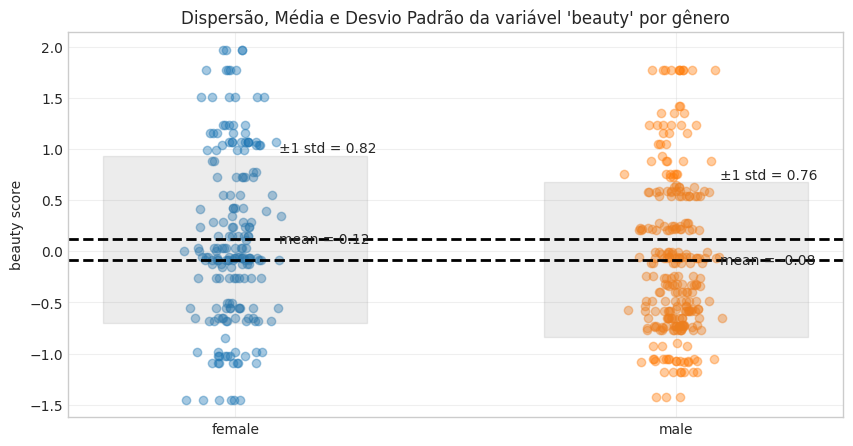

In [72]:
# Dados agregados
stats = ratings_df.groupby("gender")["beauty"].agg(["mean", "std", "var"]).reset_index()

# Preparar figura
plt.figure(figsize=(10, 5))

# Plotar pontos individuais por gênero
for i, gender in enumerate(stats["gender"]):
    values = ratings_df[ratings_df["gender"] == gender]["beauty"]
    x = np.random.normal(i, 0.04, size=len(values))  # jitter para espalhar os pontos
    plt.scatter(x, values, alpha=0.4, label=f"{gender} (n={len(values)})")

    # Linha da média
    plt.axhline(stats.loc[i, "mean"], color="black", linestyle="--", linewidth=2)
    plt.text(i + 0.1, stats.loc[i, "mean"], f"mean = {stats.loc[i, 'mean']:.2f}", verticalalignment='center')

    # Faixa de 1 desvio padrão
    mean = stats.loc[i, "mean"]
    std = stats.loc[i, "std"]
    plt.fill_between([i - 0.3, i + 0.3], mean - std, mean + std, alpha=0.15, color="gray")
    plt.text(i + 0.1, mean + std, f"±1 std = {std:.2f}", verticalalignment='bottom')

# Ajustes finais
plt.xticks([0, 1], stats["gender"])
plt.ylabel("beauty score")
plt.title("Dispersão, Média e Desvio Padrão da variável 'beauty' por gênero")
plt.grid(alpha=0.3)
plt.show()

🟠  **Como ler o gráfico**

1. Linha tracejada horizontal
    - → é a média do grupo.

2. Faixa cinza
    - → representa ± 1 desvio padrão.  
        Quanto mais larga, maior o desvio padrão.

3. Nuvem de pontos
    - → mostra a variância visualmente:  
    quanto mais espalhados, maior a variância.

4. Comparação direta
    - Mulheres: pontos mais espalhados → maior variância.
    - Homens: pontos mais concentrados → menor variância.

## 7.5 Tenure track (vaga permanente) por gênero

In [66]:
tenure_count = ratings_df[ratings_df["tenure"] == "yes"].groupby("gender").agg({"tenure": "count"}).reset_index()
tenure_count["percentage"] = 100 * tenure_count["tenure"] / tenure_count["tenure"].sum()
tenure_count

,gender,tenure,percentage
0,female,145,40.166205
1,male,216,59.833795


🟣 **Interpretação**

- A tabela mostra quantos professores com tenure existem por gênero.
- A coluna `percentage` mostra a proporção relativa entre os tenured.

<br>

🟠  **Gráfico de interpretação**

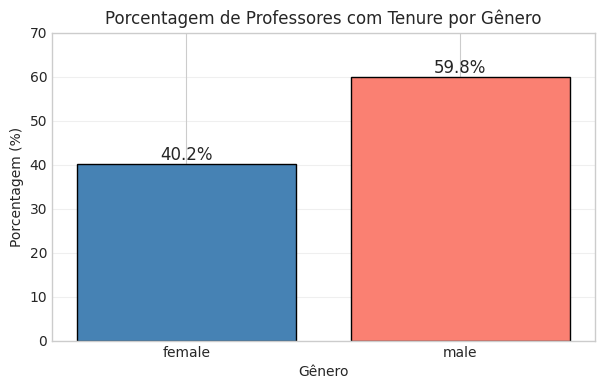

In [77]:
# Dados
tenure_count = ratings_df[ratings_df["tenure"] == "yes"].groupby("gender").agg({"tenure": "count"}).reset_index()
tenure_count["percentage"] = 100 * tenure_count["tenure"] / tenure_count["tenure"].sum()
plt.figure(figsize=(7, 4))

# Gráfico de barras
plt.bar(tenure_count["gender"], tenure_count["percentage"], color=["steelblue", "salmon"], edgecolor="black")

# Rótulos acima das barras
for i, row in tenure_count.iterrows():
    plt.text(i, row["percentage"] + 1, f"{row['percentage']:.1f}%", ha="center", fontsize=12)

# Títulos e eixos
plt.title("Porcentagem de Professores com Tenure por Gênero")
plt.ylabel("Porcentagem (%)")
plt.xlabel("Gênero")
plt.ylim(0, 70)
plt.grid(axis="y", alpha=0.3)

plt.show()


🟠  **Como interpretar o gráfico**

1. Homens têm maior proporção de tenure track  
    - A barra masculina (~60%) é visivelmente mais alta.

2. Mulheres têm menor proporção
    - A barra feminina (~40%) é mais baixa.

3. Diferença relativa
    - A diferença é de aproximadamente 20 pontos percentuais.

4. O gráfico mostra proporção, não quantidade
    - Mesmo que o número absoluto de homens seja maior,  
    o gráfico mostra a participação relativa dentro do total de professores com tenure.

---
# 8. Exercícios guiados
<a id="8-exercícios-guiados"></a>

🟣 **Exercícios para fixação**

Use estes exercícios como treino para:
- provas do curso,
- exame final,
- consolidação do raciocínio estatístico.

### Exercício 1 — Estatísticas de students

1. Calcule a média, mediana, mínimo e máximo de `students`.  
2. Compare média e mediana.  
3. O que isso sugere sobre a simetria da distribuição?

In [78]:
# TODO: seu código aqui
# Dica: use .mean(), .median(), .min(), .max()

### Exercício 2 — Beauty por gender

1. Calcule a média de `beauty` por `gender`.  
2. Calcule também o desvio padrão.  
3. Comente se há diferença relevante entre os grupos.

In [ ]:
# TODO: seu código aqui
# Dica: use groupby("gender").agg(...)

### Exercício 3 — Histograma de age

1. Crie um histograma para a variável `age`.  
2. Comente sobre a forma da distribuição (simétrica, assimétrica, concentrada, espalhada).

In [ ]:
# TODO: seu código aqui
# Dica: use plt.hist(ratings_df["age"])

### Exercício 4 — Bar plot de tenure

1. Crie um gráfico de barras para a variável `tenure`.  
2. Interprete a proporção de professores com e sem tenure.

In [ ]:
# TODO: seu código aqui
# Dica: use value_counts().plot(kind="bar")

### Exercício 5 — Mediana de eval por tenure

1. Calcule a mediana de `eval` para professores com tenure.  
2. Calcule a mediana de `eval` para professores sem tenure.  
3. Compare os resultados.

In [ ]:
# TODO: seu código aqui
# Dica: filtre por tenure == "yes" e tenure == "no"

---
# 9. Diagramas conceituais
<a id="9-diagramas-conceituais"></a>

🟣 **Mapa mental — tipos de dados**

- **Estrutura dos dados**:
  - Cross-sectional
  - Time series
  - Panel data

- **Tipo de variável**:
  - Categórica (nominal, binária, multinomial)
  - Ordinal
  - Numérica (discreta, contínua)
  - Intervalo
  - Razão

- **Ferramentas associadas**:
  - Categóricas → tabelas de frequência, gráficos de barras
  - Numéricas → média, mediana, variância, histogramas, boxplots

🟣 **Mapa mental — medidas de tendência central e dispersão**

- **Tendência central**:
  - Média → sensível a outliers
  - Mediana → robusta a outliers
  - Moda → mais frequente

- **Dispersão**:
  - Amplitude → mínimo e máximo
  - Variância → dispersão quadrática
  - Desvio padrão → dispersão na mesma unidade

- **Interpretação conjunta**:
  - Média + desvio padrão → quadro mais completo
  - Mediana + amplitude interquartil → robustez a outliers

---
# 10. Apêndice matemático avançado
<a id="10-apêndice-matemático-avançado"></a>

🟠 **Propriedades da média e da variância**




|Descrição|Função|
|-|-|
| **1. Soma dos desvios em relação à média** | $$ \sum_{i=1}^n (x_i - \bar{X}) = 0 $$ |
| **2. Variância como média dos quadrados menos quadrado da média** | $$ s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{X})^2 $$|
| Pode-se mostrar que a função **→** <br> está relacionado à variância (com ajuste de fator $ \frac{n}{n-1} $) | $$ \frac{1}{n} \sum_{i=1}^n x_i^2 - \bar{X}^2 $$ |

🟠 **População, amostra e estimadores não-viesados**

|Um estimador $ \hat{\theta} $ é dito **não-viesado** para um parâmetro $ \theta $ se:| $$ E[\hat{\theta}] = \theta $$ |
|-|-|


**→ No caso da variância:**

|- Se usássemos $ \frac{1}{n} \sum (x_i - \bar{X})^2 $, o estimador seria viesado. <br> - Usando $ \frac{1}{n-1} $, obtemos um estimador não-viesado para $ \sigma^2 $.| $$ \frac{\sum (x_i - \bar{X})^2}{n-1} $$ |
|-|-|

<br>

> Isso explica a presença do $n-1$ na fórmula da variância amostral.


---
## Encerramento

Neste módulo, você:

- entendeu a diferença entre estatística descritiva e inferencial,
- revisitou tipos de dados e estruturas (cross-sectional, time series, painel),
- consolidou os conceitos de população, amostra, parâmetros e estatísticas,
- estudou medidas de tendência central (média, mediana, moda),
- estudou medidas de dispersão (amplitude, variância, desvio padrão),
- visualizou dados com histogramas e gráficos de barras,
- aplicou tudo isso ao dataset *teaching ratings*,
- teve contato com exercícios guiados e um apêndice matemático avançado.

Este notebook pode ser:
- seu capítulo autoral do Módulo 2,
- base para o Companion Book,
- material de revisão para o exame final.